# Treinamento e Avaliação com Random Forest Regressor
Este notebook treina um modelo de regressão Random Forest para prever `preco_medio_ton_usd` e avalia o desempenho usando MSE, RMSE e R².

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
# Carregar dados

df = pd.read_csv("/content/carne-brasileira-derivada.csv")
df["date"] = pd.to_datetime(df["ano"].astype(str) + "Q" + df["trimestre"].astype(str))
df = df.sort_values(["tipo_carne", "date"]).reset_index(drop=True)

df.head()

/tmp/ipykernel_29211/3756677572.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["ano"].astype(str) + "Q" + df["trimestre"].astype(str))


,tipo_carne,ano,trimestre,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,...,exportacao_usd_diff_1,exportacao_usd_pct_change_a,preco_medio_ton_usd_lag1,preco_medio_ton_usd_lag2,preco_medio_ton_usd_lag3,preco_medio_ton_usd_lag4,preco_medio_ton_usd_rolling_mean_4,preco_medio_ton_usd_ewm_4,preco_medio_ton_usd_diff_1,preco_medio_ton_usd_pct_change_a
0,bovino,2015,1,215.20,7.737,1.836,0.993,2.87,22.95,60.01,...,-0.526,-0.261710,4.858,4.874,4.729,4.403,4.71600,4.744984,-0.579,-0.028163
1,bovino,2015,2,215.20,7.626,1.844,1.094,3.07,20.92,57.96,...,0.101,-0.209538,4.279,4.858,4.874,4.729,4.68500,4.558590,-0.049,-0.105519
2,bovino,2015,3,215.20,7.578,1.877,1.258,3.59,23.80,69.05,...,0.164,-0.186813,4.230,4.279,4.858,4.874,4.56025,4.427154,0.328,-0.064834
3,bovino,2015,4,215.20,7.693,1.929,1.319,3.83,27.76,70.20,...,0.061,-0.131666,4.558,4.230,4.279,4.858,4.48125,4.479493,-0.336,-0.130918
4,bovino,2016,1,218.23,7.303,1.797,1.094,3.82,36.46,65.52,...,-0.225,0.101712,4.222,4.558,4.230,4.279,4.32225,4.376496,0.008,-0.011451


In [31]:
# Configurar target e tipos de carne

target_column = "preco_medio_ton_usd"
meat_types = df["tipo_carne"].unique()
print("Tipos de carne:", meat_types)

Tipos de carne: ['bovino' 'frango' 'suino']


In [32]:
# Engenharia de features

feature_columns = [
    'preco_medio_ton_usd_lag1',
    'preco_medio_ton_usd_lag2',
    'preco_medio_ton_usd_lag3',
    'exportacao_usd_lag1',
    'media_cambio_usdbrl',
    'custo_milho_rs',
]

print("Features usadas:", feature_columns)

Features usadas: ['preco_medio_ton_usd_lag1', 'preco_medio_ton_usd_lag2', 'preco_medio_ton_usd_lag3', 'exportacao_usd_lag1', 'media_cambio_usdbrl', 'custo_milho_rs']



=== Tipo de carne: bovino ===
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Melhores parâmetros: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Melhor score (neg MSE): -0.7168366320440335
Amostras de treino: 29
Amostras de teste: 8
MSE: 0.0826
RMSE: 0.2875
R²: -1.4479
Top 20 features por importância:
custo_milho_rs              0.448237
preco_medio_ton_usd_lag1    0.242316
preco_medio_ton_usd_lag3    0.137369
media_cambio_usdbrl         0.089437
exportacao_usd_lag1         0.043438
preco_medio_ton_usd_lag2    0.039203
dtype: float64


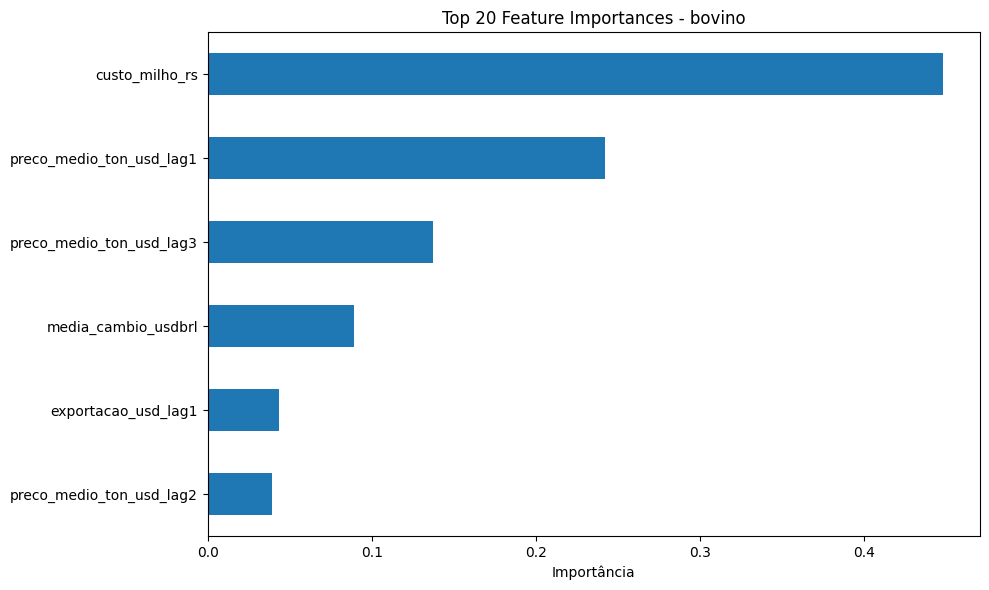

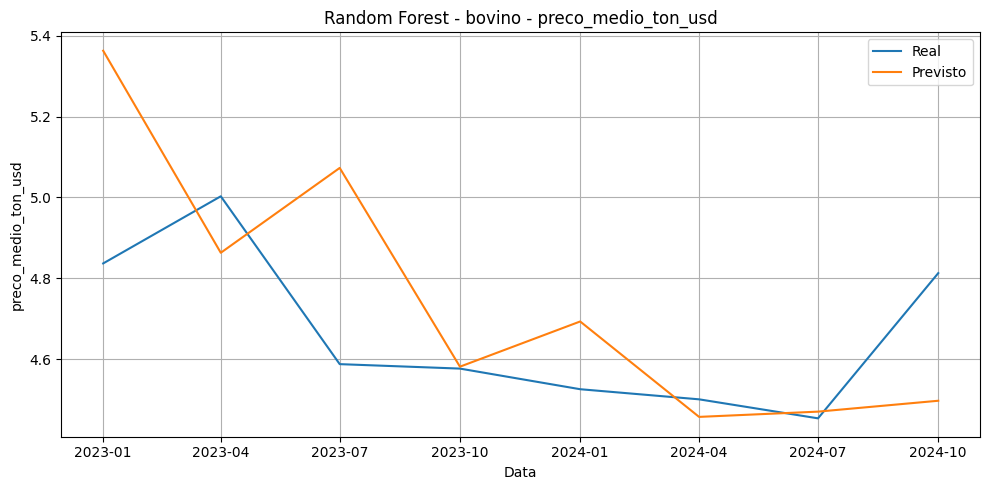


=== Tipo de carne: frango ===
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Melhores parâmetros: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 150}
Melhor score (neg MSE): -0.05570946736959049
Amostras de treino: 29
Amostras de teste: 8
MSE: 0.0140
RMSE: 0.1181
R²: -0.9701
Top 20 features por importância:
preco_medio_ton_usd_lag1    0.384268
exportacao_usd_lag1         0.299084
custo_milho_rs              0.236434
preco_medio_ton_usd_lag3    0.053817
preco_medio_ton_usd_lag2    0.018452
media_cambio_usdbrl         0.007945
dtype: float64


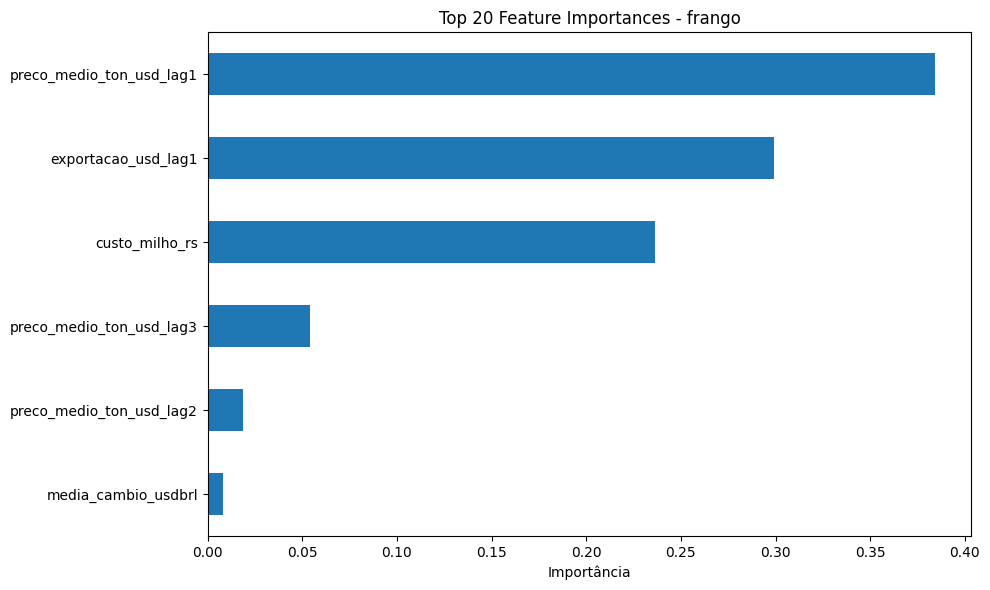

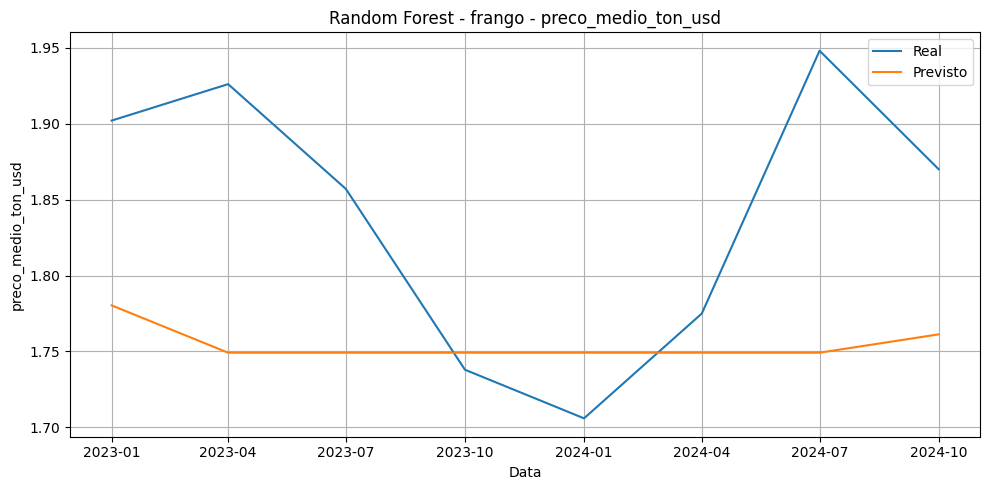


=== Tipo de carne: suino ===
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Melhores parâmetros: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 150}
Melhor score (neg MSE): -0.021806714177965276
Amostras de treino: 29
Amostras de teste: 8
MSE: 0.0071
RMSE: 0.0841
R²: 0.4337
Top 20 features por importância:
exportacao_usd_lag1         0.652049
preco_medio_ton_usd_lag3    0.091066
preco_medio_ton_usd_lag2    0.069890
preco_medio_ton_usd_lag1    0.067980
custo_milho_rs              0.064743
media_cambio_usdbrl         0.054271
dtype: float64


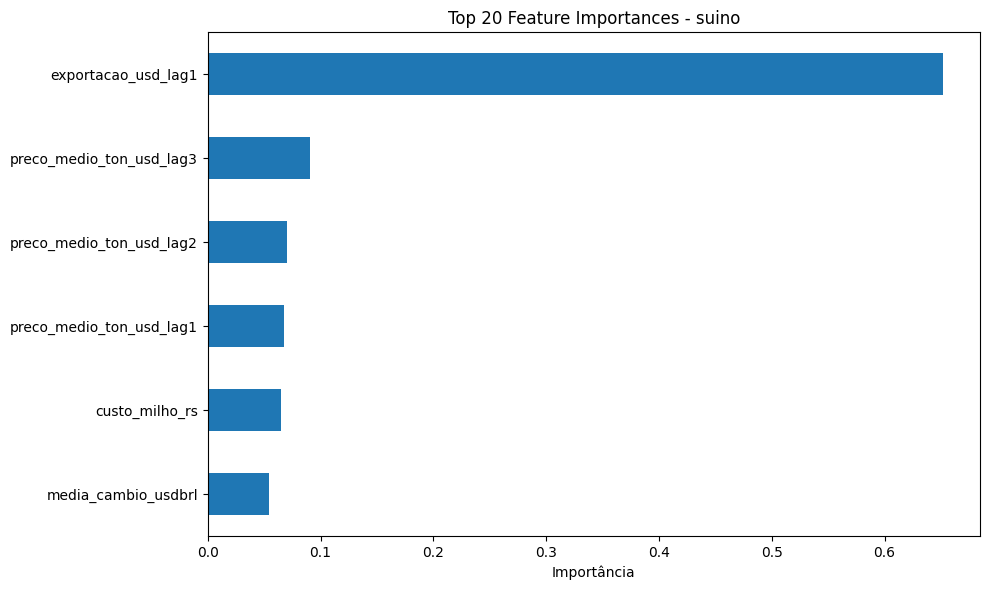

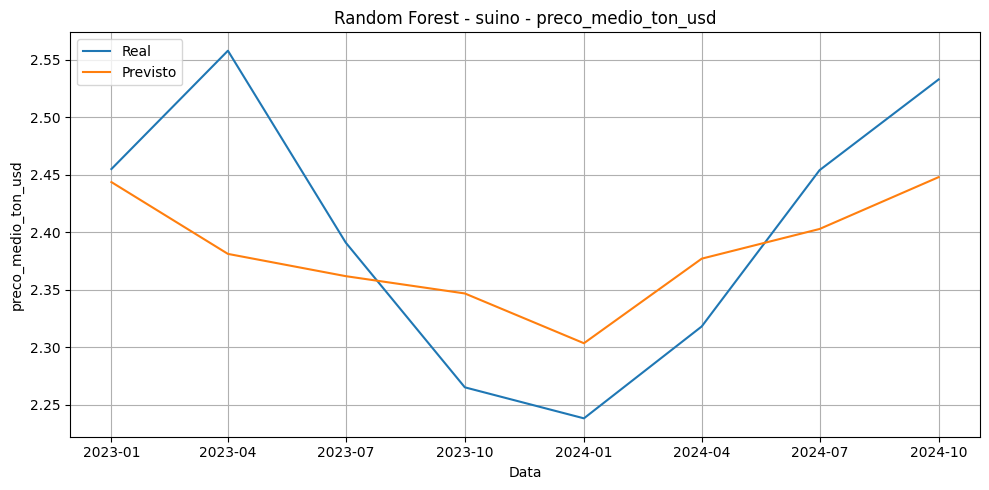


Resumo por tipo de carne:
  tipo_carne       mse      rmse        r2  n_train  n_test
0     bovino  0.082644  0.287479 -1.447927       29       8
1     frango  0.013957  0.118141 -0.970056       29       8
2      suino  0.007068  0.084072  0.433700       29       8


In [33]:
# Treinamento e avaliação para todos os tipos de carne

tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    'n_estimators': [150, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 5],
}

results = []

for meat_type in meat_types:
    print(f"\n=== Tipo de carne: {meat_type} ===")
    df_filtered = df[df["tipo_carne"] == meat_type].copy()
    df_filtered = df_filtered.sort_values("date").reset_index(drop=True)

    df_filtered[f"{target_column}_lag1"] = df_filtered[target_column].shift(1)
    df_filtered[f"{target_column}_lag2"] = df_filtered[target_column].shift(2)
    df_filtered[f"{target_column}_lag3"] = df_filtered[target_column].shift(3)
    df_filtered["exportacao_usd_lag1"] = df_filtered["exportacao_usd"].shift(1)

    df_model = df_filtered.dropna(subset=feature_columns + [target_column]).reset_index(drop=True)
    train_size = int(len(df_model) * 0.8)
    train = df_model.iloc[:train_size]
    test = df_model.iloc[train_size:]

    X_train = train[feature_columns]
    y_train = train[target_column]
    X_test = test[feature_columns]
    y_test = test[target_column]

    grid_search = GridSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid,
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)

    print('Melhores parâmetros:', grid_search.best_params_)
    print('Melhor score (neg MSE):', grid_search.best_score_)

    model = grid_search.best_estimator_
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    print(f"Amostras de treino: {len(X_train)}")
    print(f"Amostras de teste: {len(X_test)}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

    feature_importances = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
    print("Top 20 features por importância:")
    print(feature_importances.head(20))

    plt.figure(figsize=(10, 6))
    feature_importances.head(20).plot(kind='barh')
    plt.gca().invert_yaxis()
    plt.title(f"Top 20 Feature Importances - {meat_type}")
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(test["date"].reset_index(drop=True), y_test.values, label="Real")
    plt.plot(test["date"].reset_index(drop=True), predictions, label="Previsto")
    plt.title(f"Random Forest - {meat_type} - {target_column}")
    plt.xlabel("Data")
    plt.ylabel(target_column)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    results.append({
        'tipo_carne': meat_type,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'n_train': len(X_train),
        'n_test': len(X_test),
    })

results_df = pd.DataFrame(results)
print("\nResumo por tipo de carne:")
print(results_df)
